# Get s2 values from CDS to a dataframe

In [2]:
import os

os.environ["PROJ_LIB"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["PROJ_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["GDAL_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/gdal"

In [3]:
import teledetection # old : import dinamis_sdk
import pystac_client
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from path import Path
import pystac_client
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
from path import Path
#import pystac_client
import stackstac
import time
import planetary_computer as pc
#from simplestac.utils import ItemCollection, apply_formula, drop_assets_without_proj

In [4]:
import warnings
from rasterio import logging


In [5]:
from pyproj import CRS

print(CRS.from_epsg(2154))


EPSG:2154


In [7]:
gdf = gpd.read_file("../data/RNN_limite_poly_l93.shp")

gdf = gdf.set_crs("EPSG:2154")

gdf = gdf.to_crs("EPSG:4326")


gdf2 = gpd.read_file("../data/limite_RI_wgs84.shp")
gdf2 = gdf2.set_crs("EPSG:4326")

/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Geometry of polygon of fid 0 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.
  return ogr_read(


In [9]:
#virer les warnings de rasterio
warnings.filterwarnings("ignore")
log = logging.getLogger()
log.setLevel(logging.ERROR)

In [10]:
# Load the area of interest
roi_file = "../data/emprise_massane.geojson"
# Lire le fichier GeoJSON
#roi = gpd.read_file(roi_file)
#print(roi.total_bounds)
roi = gdf

In [11]:
URL = "https://stacapi-cdos.apps.okd.crocc.meso.umontpellier.fr"
api = pystac_client.Client.open(URL)

collections = [(collection.id, collection.title) for collection in api.get_collections()]
pd.set_option('display.max_rows', 150)
pd.DataFrame(collections, columns=['Collection ID', 'Collection Title']).sort_values(by='Collection ID')

,Collection ID,Collection Title
10,FORMSpoT,FORMSpoT
11,FORMSpoT-delta,FORMSpoT-∆
0,becarun,Lidar BECARUN (COPC)
1,cartofeux-lidarhd,Lidar HD point cloud for project CARTO-FEUX
2,cesbio-s2albedo,Albédo de surface Sentinel-2
3,corona-4b,Corona 4B
4,costarica-sentinel-2-l2-spectral-indices,costarica-sentinel-2-l2-spectral-indices
5,costarica-sentinel-2-l3-seasonal-spectral-indices,costarica-sentinel-2-l3-seasonal-spectral-indices
6,costarica-sentinel-2-l3-seasonal-spectral-indi...,costarica-sentinel-2-l3-seasonal-spectral-indi...
7,costarica-sentinel-2-l4-seasonal-diversity-ind...,costarica-sentinel-2-l4-seasonal-diversity-ind...


In [12]:
tile = "31TEH"
start_date = "2016-01-01"
end_date = "2026-06-01"
time_range = start_date + "/" + end_date
#time_range = "2024-03-01/2024-03-20"
#cloud_nb = 10
# bbox=[3.00, 42.47, 3.04, 42.5]

# file where the collection will be saved

catalog = pystac_client.Client.open(URL, modifier=teledetection.sign_inplace)
search = catalog.search(
    collections=["sentinel2-l2a-theia"],  ##CDS
    #collections=["sentinel-2-l2a"], ##Planetary
    # bbox=bbox,
    bbox=roi.to_crs(4326).total_bounds,
    datetime=time_range,
    #query={"eo:cloud_cover": {"lt": cloud_nb}},
    query={"s2:mgrs_tile": {"eq": tile}}
    #query={"s2:mgrs_tile": {"eq": tile},"eo:cloud_cover": {"lt": cloud_nb} },
)
items = search.get_all_items()
print(f"{len(items)} items found")


1075 items found


In [13]:
from simplestac.utils import ItemCollection

df = gpd.GeoDataFrame.from_features(items.to_dict(), crs="epsg:4326")


In [14]:
# Make the search result an extended ItemCollection, i.e. with extended methods
col = ItemCollection(search.item_collection(), clone_items=False).sort_items(by="datetime")

Filled property fields with None when missing in items:
{'updated'}


In [15]:
item = col[0]
print(item.assets.keys())

dict_keys(['MD', 'QL', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B11', 'B12', 'B8A', 'ATB_R1', 'ATB_R2', 'CLM_R1', 'CLM_R2', 'EDG_R1', 'EDG_R2', 'MG2_R1', 'MG2_R2', 'SAT_R1', 'SAT_R2'])


In [16]:
# Drop non raster assets
col.drop_non_raster(inplace=True)
col = col.filter(assets=["B04", "B08" , "CLM_R1"]) #CDS_MTD

In [18]:
from simplestac.utils import apply_formula

col.drop_non_raster(inplace=True)
col.apply_items(
    fun=apply_formula, # a function that returns one or more xarray.DataArray
    name="NDVI",
    formula="((B08 - B04) / (B08 + B04))", #NDVI
    output_dir="NDVI",
    #datetime="2018-01-01/..",
    geometry=roi.geometry,
    inplace=True
)

xar = col.to_xarray(geometry=roi.geometry, epsg=4326)
# #xar = col.to_xarray(geometry= geometrie)
xar.drop_duplicates('time')

100%|██████████| 1075/1075 [28:01<00:00,  1.56s/it] 


<xarray.DataArray 'stackstac-d92de08d56ee812716258a8298786fa1' (time: 1075,
                                                                band: 4,
                                                                y: 354, x: 335)> Size: 4GB
dask.array<getitem, shape=(1075, 4, 354, 335), dtype=float64, chunksize=(1, 1, 354, 335), chunktype=numpy.ndarray>
Coordinates: (12/38)
  * time                      (time) datetime64[ns] 9kB 2016-01-16T10:39:08.2...
    id                        (time) <U43 185kB 'SENTINEL2A_20160116-103908-2...
    platform                  (time) <U3 13kB 'S2A' 'S2A' 'S2A' ... 'S2B' 'S2A'
    sat:relative_orbit        (time) int64 9kB 108 8 8 108 8 ... 108 108 8 108 8
    eo:cloud_cover            (time) float64 9kB 57.0 85.0 85.0 ... 0.0 4.0 11.0
    updated                   (time) object 9kB '2026-01-28T07:15:06.021076Z'...
    ...                        ...
    production:version        <U5 20B '0.6.2'
    instruments               <U3 12B 'MSI'
    proj:epsg                 int64 8B 32631
    proj:code                 <U10 40B 'EPSG:32631'
    epsg                      int64 8B 4326
    spatial_ref               int64 8B 0
Attributes:
    spec:           RasterSpec(epsg=4326, bounds=(np.float64(2.99970159970225...
    resolution_xy:  (np.float64(0.00012170162283764441), np.float64(9.0045532...

In [19]:
clm = xar.sel(band="CLM_R1") #cloud mask extraction
mask = (clm>10).astype(bool)
#mask
mask_proportion = round(np.count_nonzero(mask) / mask.size*100, 2)
# mask_proportion
print(f"Proportion of clouds in image over the time series is {mask_proportion} % ")

Proportion of clouds in image over the time series is 6.55 % 


In [20]:
#Mask NDVI
arr_ndvi= xar.where(~mask).sel(band=["NDVI"])
arr_ndvi.drop_duplicates('time')

<xarray.DataArray 'stackstac-d92de08d56ee812716258a8298786fa1' (time: 1075,
                                                                band: 1,
                                                                y: 354, x: 335)> Size: 1GB
dask.array<getitem, shape=(1075, 1, 354, 335), dtype=float64, chunksize=(1, 1, 354, 335), chunktype=numpy.ndarray>
Coordinates: (12/32)
  * time                      (time) datetime64[ns] 9kB 2016-01-16T10:39:08.2...
    id                        (time) <U43 185kB 'SENTINEL2A_20160116-103908-2...
    platform                  (time) <U3 13kB 'S2A' 'S2A' 'S2A' ... 'S2B' 'S2A'
    sat:relative_orbit        (time) int64 9kB 108 8 8 108 8 ... 108 108 8 108 8
    eo:cloud_cover            (time) float64 9kB 57.0 85.0 85.0 ... 0.0 4.0 11.0
    updated                   (time) object 9kB '2026-01-28T07:15:06.021076Z'...
    ...                        ...
    production:version        <U5 20B '0.6.2'
    instruments               <U3 12B 'MSI'
    proj:epsg                 int64 8B 32631
    proj:code                 <U10 40B 'EPSG:32631'
    epsg                      int64 8B 4326
    spatial_ref               int64 8B 0
Attributes:
    spec:           RasterSpec(epsg=4326, bounds=(np.float64(2.99970159970225...
    resolution_xy:  (np.float64(0.00012170162283764441), np.float64(9.0045532...

In [33]:
clipped = xar.sel(band="NDVI").rio.clip(
    gdf2.geometry,
    gdf2.crs,
    drop=True
)

In [34]:
spatial_mask = np.isfinite(
    clipped.isel(time=0).values
)

In [35]:
masked = clipped.where(~mask)

In [36]:
dates = []
mean_ndvi = []
ratio_valid = []

n_total = spatial_mask.sum()

for t in range(masked.sizes["time"]):

    ndvi_t = masked.isel(time=t)

    values = ndvi_t.values

    valid = np.isfinite(values)

    ratio = valid.sum() / n_total

    if ratio >= 0.8:

        dates.append(
            pd.to_datetime(str(ndvi_t.time.values))
        )

        mean_ndvi.append(
            float(np.nanmean(values))
        )

        ratio_valid.append(ratio)

In [37]:
df_s2 = pd.DataFrame({
    "date": dates,
    "mean_ndvi_s2": mean_ndvi,
    "ratio_valid": ratio_valid
})

In [39]:
df_s2 = df_s2[df_s2["mean_ndvi_s2"] >= 0.35]

<Axes: xlabel='date'>

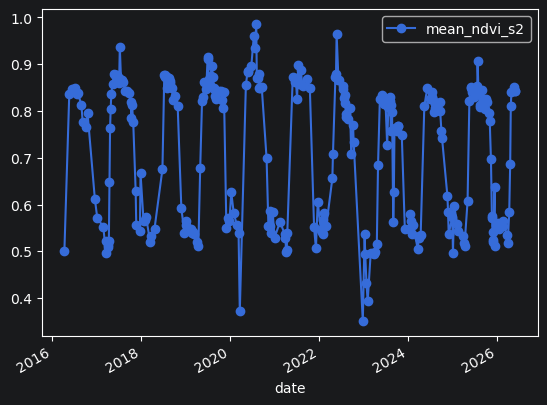

In [40]:
df_s2.plot(
    x="date",
    y="mean_ndvi_s2",
    marker="o"
)

# export the s2 dataset

In [41]:
df_s2.to_csv("../output/NDVI_S2_RI_2016_2026.csv", index=False, float_format="%.3f", columns=["date", "mean_ndvi_s2"])